# Objectif du notebook 

Date de création : 11/12/2025

L'objectif du notebook est de faire une première analyse des données AIS afin : 

* de valider le code d'extraction des positions GPS à partir des trames AIS
* d'identifier des trajectoires de navires exploitable pour la mise en œuvre du procédé d'inversion des positions des OBS 
* d'identifier des trajectoires de navires exploitables pour la mise en œuvre de la localisation RTF-MFP. 

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_metadata = os.path.join(root_groix_data, "metadata")
root_groix_ais = os.path.join(root_groix_data, "ais")
if not os.path.exists(root_groix_ais):
    os.makedirs(root_groix_ais)
root_groix_gps = os.path.join(root_groix_data, "gps")
if not os.path.exists(root_groix_gps):
    os.makedirs(root_groix_gps)

root_ais_not_parsed = r"C:\Users\baptiste.menetrier\Desktop\ressource\XP_Fiberscope_Groix_092025\Jules\ais"
root_gps_not_parsed = r"C:\Users\baptiste.menetrier\Desktop\ressource\XP_Fiberscope_Groix_092025\Jules\gps"

In [3]:
sys.path.append(project_root)

from source.utils.utils_ais import ais_file_to_csv
from source.utils.utils_gps import (
    gpx_to_csv,
    interpolate_gps,
)
from publication.publication_figure import LargeFigure, PubFigure, color

# Lectures des trames AIS et extraction des positions AIS

Le code ci-dessous permet de décoder les données AIS fournies par Didier (données de l'antenne AIS au sémaphore). L'horodatage des trames, à partir des messages NMEA GPS (trames $GPRMC) n'est pas fonctionnel en l'état en raison de son manque de robustesse. En particulier, l'horodatage plante en raison de certaines trames erronées. 

In [4]:
# # Get all files within subfolders : folder = 13_10_25; files 13_10_25.txt
# for root, dirs, files in os.walk(root_ais_not_parsed):
#     for file in files:
#         if file.endswith(".txt"):
#             print(f"Processing AIS file: {file}")
#             fpath_in = os.path.join(root, file)
#             fname = os.path.splitext(file)[0]
#             root_output = os.path.join(root_groix_ais, os.path.basename(root))
#             fpath_out = os.path.join(root_output, f"ais_pos_{fname}.csv")
#             if not os.path.exists(root_output):
#                 os.makedirs(root_output)
#             ais_file_to_csv(input_file=fpath_in, output_file=fpath_out)


Dans la suite on utilisera donc les données AIS détramées par le SHOM et contenu dans le fichier SPATIONAV_AIS_001.csv

In [5]:
# Chargement des données AIS détramées par le SHOM 
ais_spationav_fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\ais\SPATIONAV_AIS_001.csv"
columns = ["mmsi", "lon", "lat", "datetime"]
df_ais_spationav = pd.read_csv(ais_spationav_fpath, sep="\t", names=columns, header=None, usecols=[1, 2, 3, 4])

# Convert datetime column to datetime objects
df_ais_spationav["datetime"] = pd.to_datetime(df_ais_spationav["datetime"], format="%Y-%m-%d %H:%M:%S", utc=True)

# MMSI du Jules
mmsi_jules = 226916000
df_ais_jules = df_ais_spationav.loc[df_ais_spationav["mmsi"] == mmsi_jules]

# Représentation de trajectoires 

## Chargement des données pour le fond de carte 

In [6]:
# Chargement des positions a priori
apriori_pos_wgs84 = pd.read_csv(
    os.path.join(root_groix_metadata, "pos_deg.csv"), index_col=0
)
# Ajout d'une hauteur (aléatoire pour l'instant)
# En vrai il faut surement chercher la hauteur du géoid au dessus de l'éllispoid WGS84
# et y retrancher l'immersion du capteur (immersion par rapport au niveau moyen de la mer donnée par
# la moyenne des mesures de pression du capteur de pression).
apriori_pos_wgs84["h"] = -25 + np.random.normal(
    loc=0, scale=1, size=apriori_pos_wgs84.shape[0]
)
# Coordonnées de le l'origine du repère de référence
obs_pos_id = "obs2"
pos0 = apriori_pos_wgs84.loc[obs_pos_id]
lat0 = np.radians(pos0.lat)
lon0 = np.radians(pos0.lon)
h0 = pos0.h

In [7]:
# Load bathy data
input_data_root = os.path.join(project_root, "data")
bathy_fpath = os.path.join(input_data_root, "bathy", "GEBCO_2021_sub_ice_topo.nc")
# bathy_fpath = r"/home/program/ubf_tools/data/bathy/mmdpm/PVA_RR48/GEBCO_2021_lon_64.44_67.44_lat_-29.08_-26.08.nc"

ds_bathy = xr.open_dataset(bathy_fpath)

# Slice data to get the area of interest
dlat_box = 0.1
dlon_box = 0.1
ds_bathy = ds_bathy.sel(
    lat=slice(
        pos0.lat - dlat_box,
        pos0.lat + dlat_box,
    ),
    lon=slice(
        pos0.lon - dlon_box,
        pos0.lon + dlon_box,
    ),
)

In [8]:
def plot_trajectory(df_ais, date, mmsi, ds_bathy, label=None, marker=None):
    # Plot bathymetry and trajectory
    pfig = LargeFigure(legend_fontsize=20)
    plt.figure()
    ds_bathy.elevation.plot()
    # Add contours
    plt.contour(
        ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[-0], colors="black"
    )

    # Select day
    df_ais_date = df_ais.loc[df_ais["datetime"].dt.date == pd.to_datetime(date).date()]
    mmsi = np.atleast_1d(mmsi)
    for i, mmsi_i in enumerate(mmsi):
        # Select the vessel by its MMSI
        df_ais_vessel = df_ais_date.loc[df_ais_date["mmsi"] == mmsi_i]

        if label == "mmsi":
            label_i = str(mmsi_i)
        else:
            label_i = label

        # Positions du navire
        plt.plot(
            df_ais_vessel["lon"],
            df_ais_vessel["lat"],
            color=color(i),
            label=label_i,
            zorder=2,
            marker=marker, 
            markersize=3,
        )
    # plt.legend()
    plt.title(date)

## Trajectoire du Jules chaque jour 

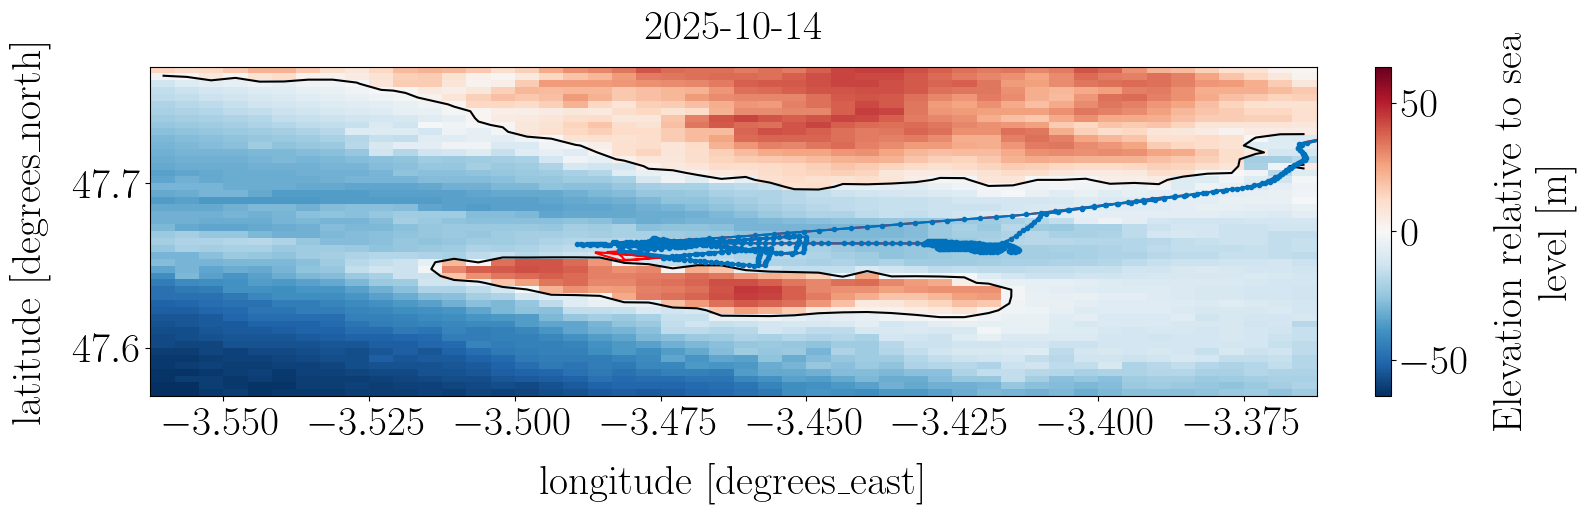

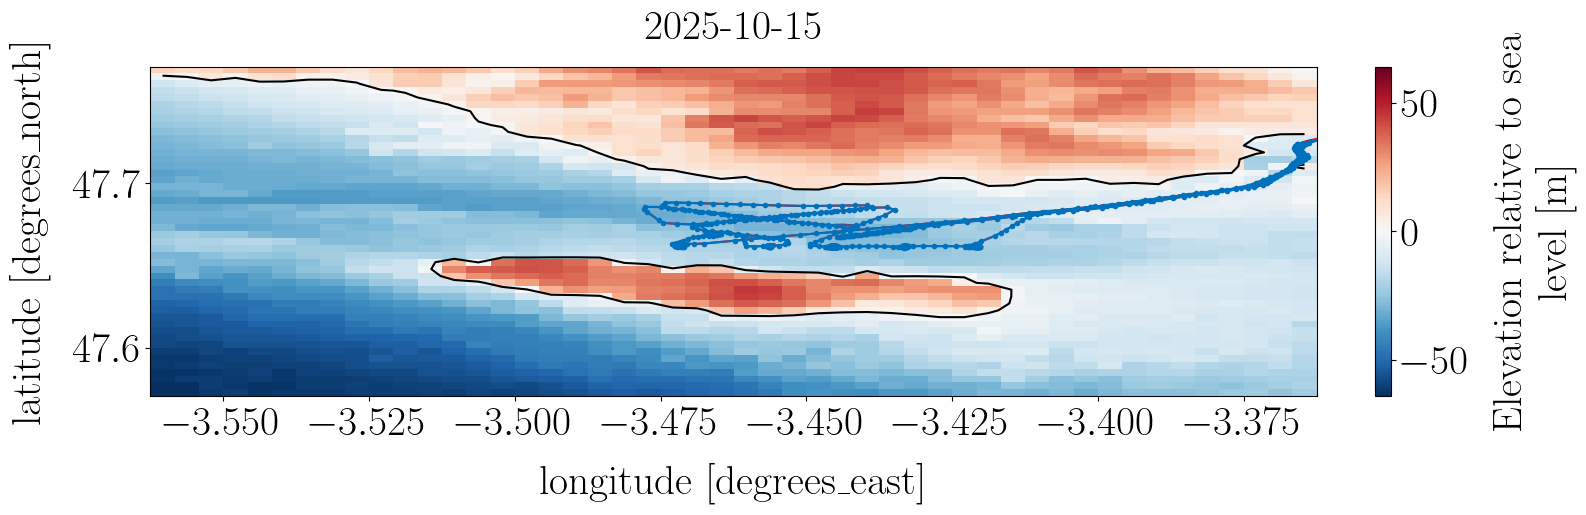

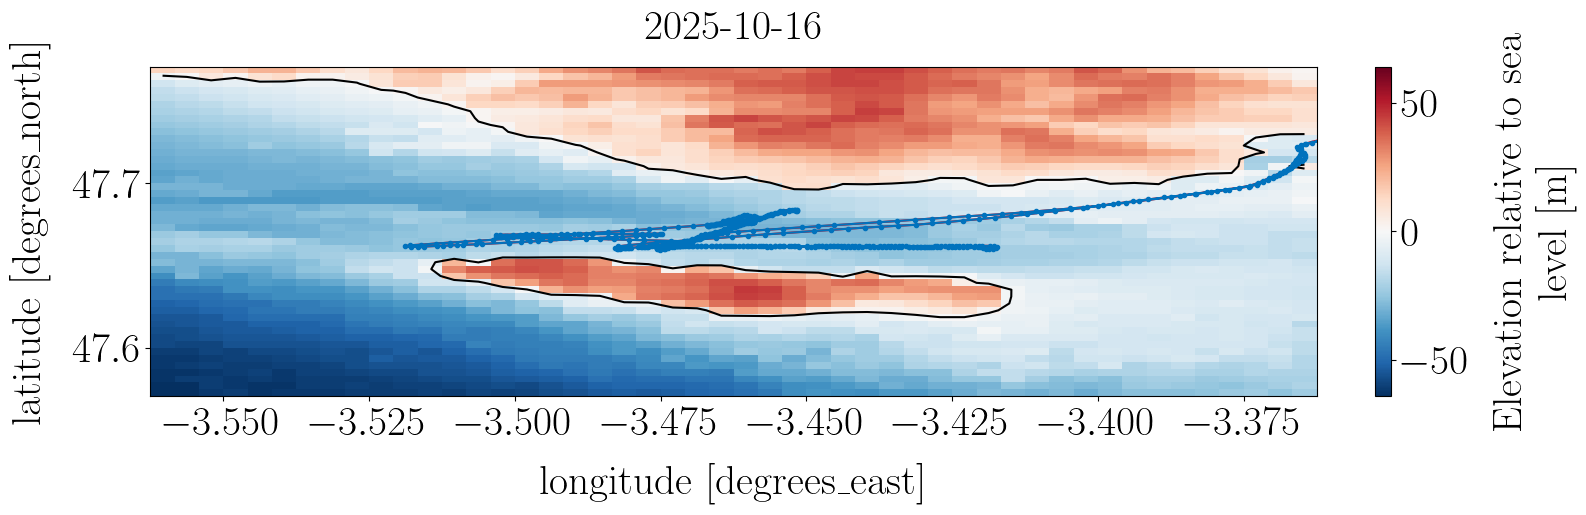

In [9]:
# Date
dates_old = [f"{13+i:02d}_10_25" for i in range(1, 4)]
dates = [f"2025-10-{13+i:02d}" for i in range(1, 4)]
for i, date in enumerate(dates):
    plot_trajectory(df_ais_spationav, date, mmsi_jules, ds_bathy, marker="o")    

    # Load AIS data
    date_o = dates_old[i]
    ais_fpath = os.path.join(
        root_groix_ais,
        date_o,
        f"ais_pos_{date_o}.csv",
    )
    df_ais_bis = pd.read_csv(ais_fpath, sep=",")
    df_ais_bis = df_ais_bis.loc[df_ais_bis["mmsi"] == mmsi_jules]

    plt.plot(
        df_ais_bis["lon"],
        df_ais_bis["lat"],
        color="red",
        label="AIS Bapt",
        zorder=1,
        # s=10,
    )

## Trajectoires des autres navires dans la zone 

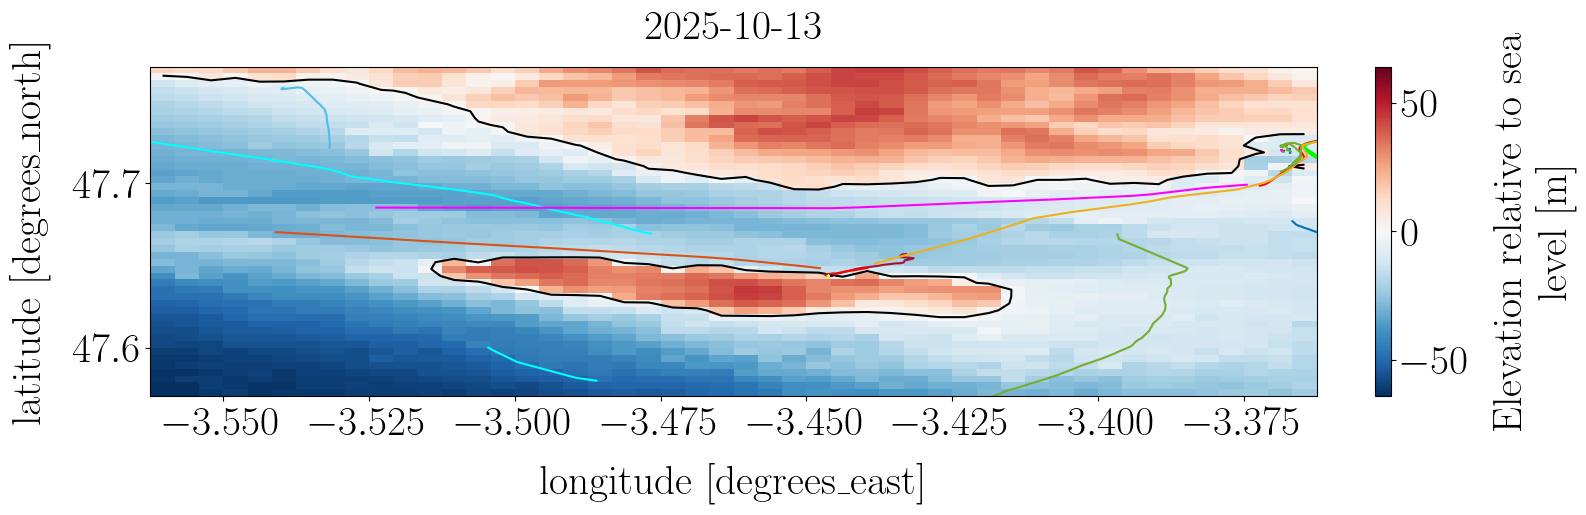

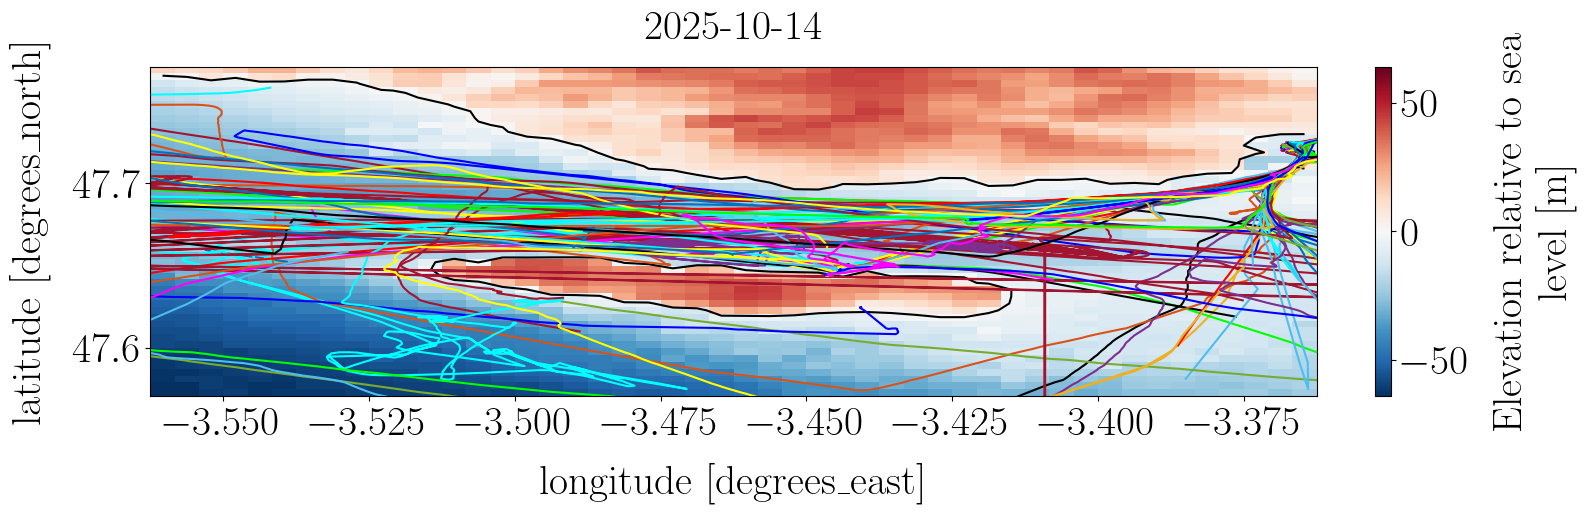

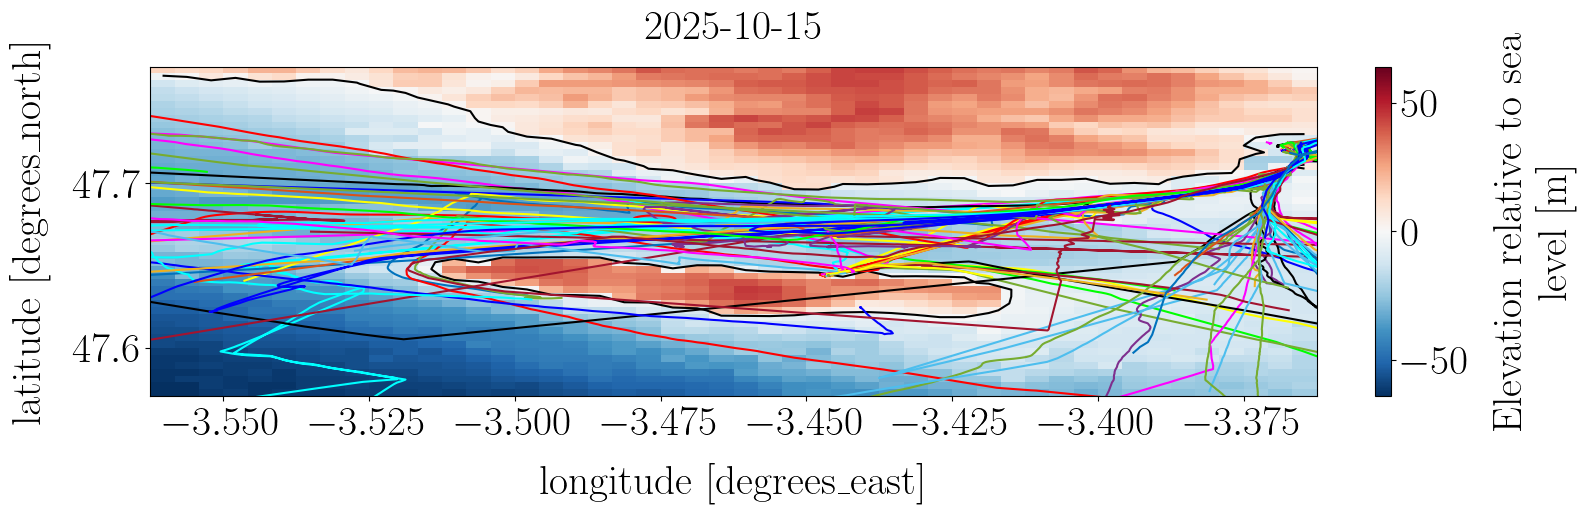

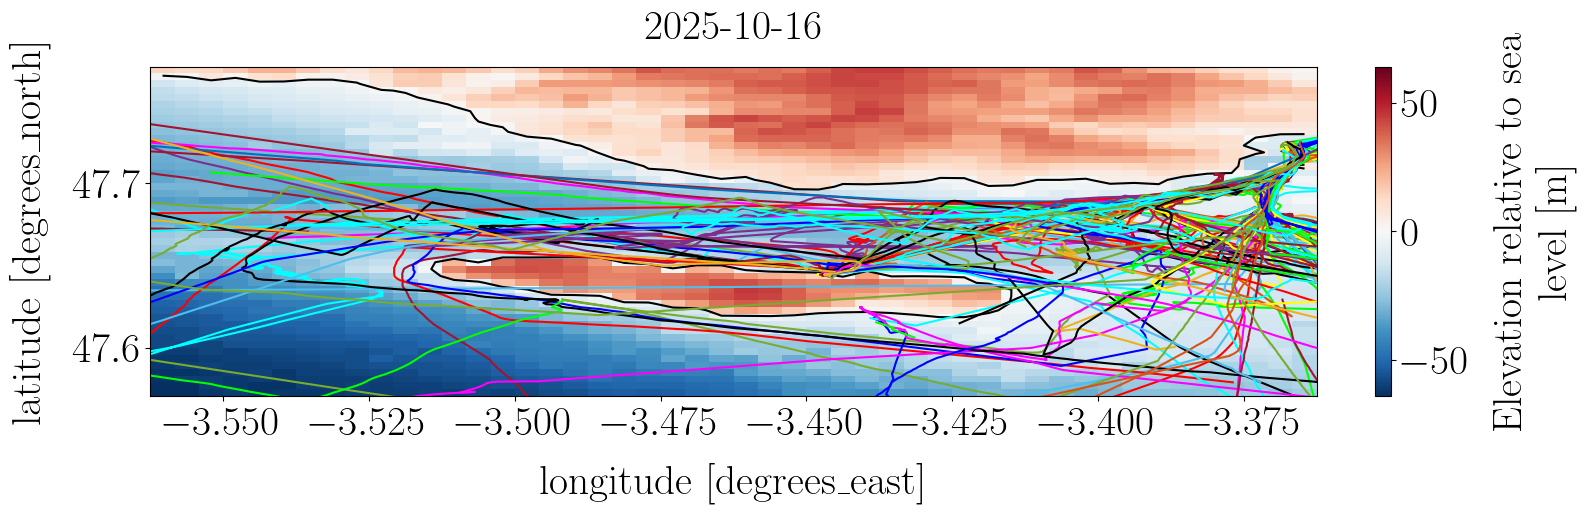

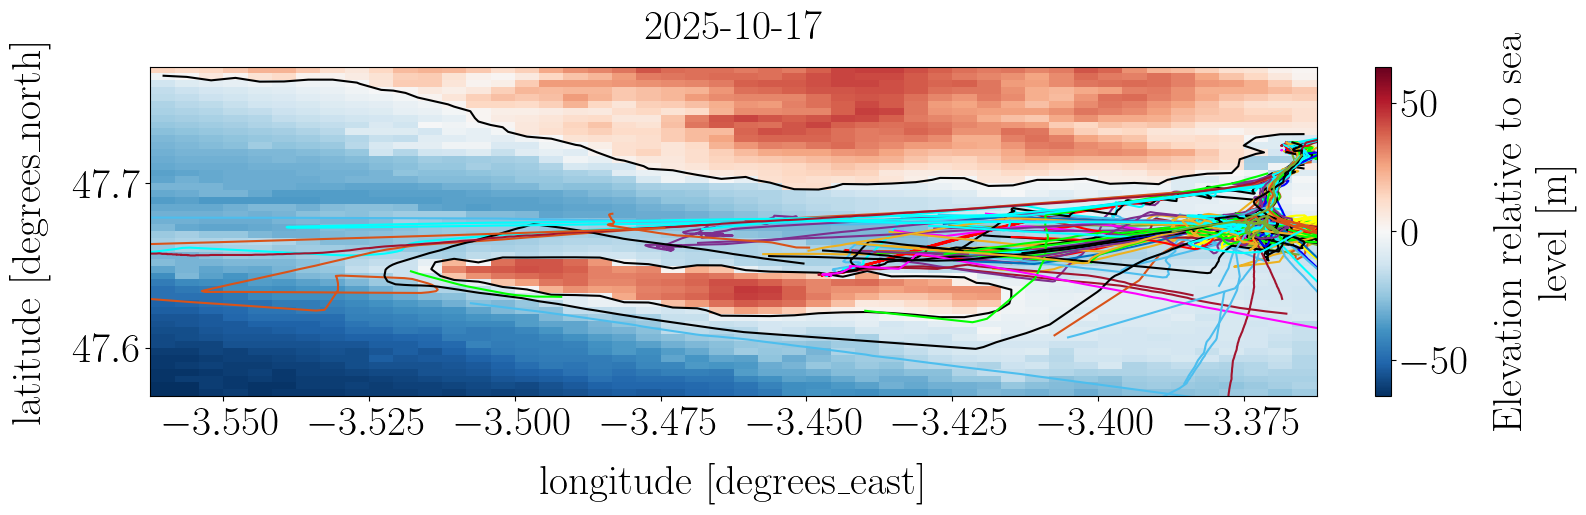

In [10]:
# n_mmsi = 100

mmsi = df_ais_spationav.mmsi.unique()
dates = df_ais_spationav["datetime"].dt.date.unique()
dates.sort()
for i, date in enumerate(dates):
    plot_trajectory(df_ais_spationav, date, mmsi, ds_bathy)


## Lectures des données GPS au format (GPX) et extraction des positions 

In [11]:
# Get all files within subfolders : folder = 13_10_25; files 13_10_25.txt
for root, dirs, files in os.walk(root_gps_not_parsed):
    for file in files:
        if file.endswith(".gpx"):
            fpath_in = os.path.join(root, file)
            fname = os.path.splitext(file)[0]
            root_output = os.path.join(root_groix_gps, os.path.basename(root))
            fpath_out = os.path.join(root_output, f"gps_pos_{fname}.csv")
            if not os.path.exists(root_output):
                os.makedirs(root_output)
            gpx_to_csv(gpx_file=fpath_in, csv_file=fpath_out)

✔ Conversion GPX → CSV terminée.
✔ 630 points GPS exportés dans c:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\gps\14_10_25\gps_pos_trace_14_10_25.csv.
✔ Conversion GPX → CSV terminée.
✔ 681 points GPS exportés dans c:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\gps\15_10_25\gps_pos_trace_15_10_25.csv.
✔ Conversion GPX → CSV terminée.
✔ 701 points GPS exportés dans c:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\gps\16_10_25\gps_pos_trace_16_10_25.csv.


## Chargement des données et représentation des positions GPS 

In [12]:
gps_pos = {}

for root, dirs, files in os.walk(root_groix_gps):
    for file in files:
        if file.endswith(".csv"):
            fpath_in = os.path.join(root, file)
            df_gps = pd.read_csv(fpath_in, sep=",")

            # Drop elevation column 
            if "ele" in df_gps.columns:
                df_gps = df_gps.drop(columns=["ele"])

            # Convert time column to datetime
            df_gps["datetime"] = pd.to_datetime(df_gps["time"])

            # Drop original time column
            df_gps = df_gps.drop(columns=["time"])

            # Store in dictionary
            date = df_gps["datetime"].dt.date.unique()[0].strftime("%Y-%m-%d")
            # date = os.path.basename(root)
            gps_pos[date] = df_gps

print(gps_pos)

{'2025-10-14':            lat       lon                  datetime
0    47.659612 -3.419953 2025-10-14 08:29:30+00:00
1    47.659575 -3.419873 2025-10-14 08:29:36+00:00
2    47.659495 -3.419913 2025-10-14 08:29:44+00:00
3    47.659415 -3.419777 2025-10-14 08:29:58+00:00
4    47.659397 -3.418837 2025-10-14 08:31:00+00:00
..         ...       ...                       ...
625  47.663520 -3.478957 2025-10-14 14:46:46+00:00
626  47.663717 -3.478367 2025-10-14 14:46:56+00:00
627  47.664423 -3.475412 2025-10-14 14:47:34+00:00
628  47.665415 -3.471815 2025-10-14 14:48:19+00:00
629  47.665890 -3.469827 2025-10-14 14:48:40+00:00

[630 rows x 3 columns], '2025-10-15':            lat       lon                  datetime
0    47.679485 -3.416652 2025-10-15 07:12:59+00:00
1    47.677463 -3.423428 2025-10-15 07:14:10+00:00
2    47.676115 -3.427747 2025-10-15 07:14:56+00:00
3    47.675192 -3.430525 2025-10-15 07:15:26+00:00
4    47.674548 -3.432317 2025-10-15 07:15:46+00:00
..         ...       ...    

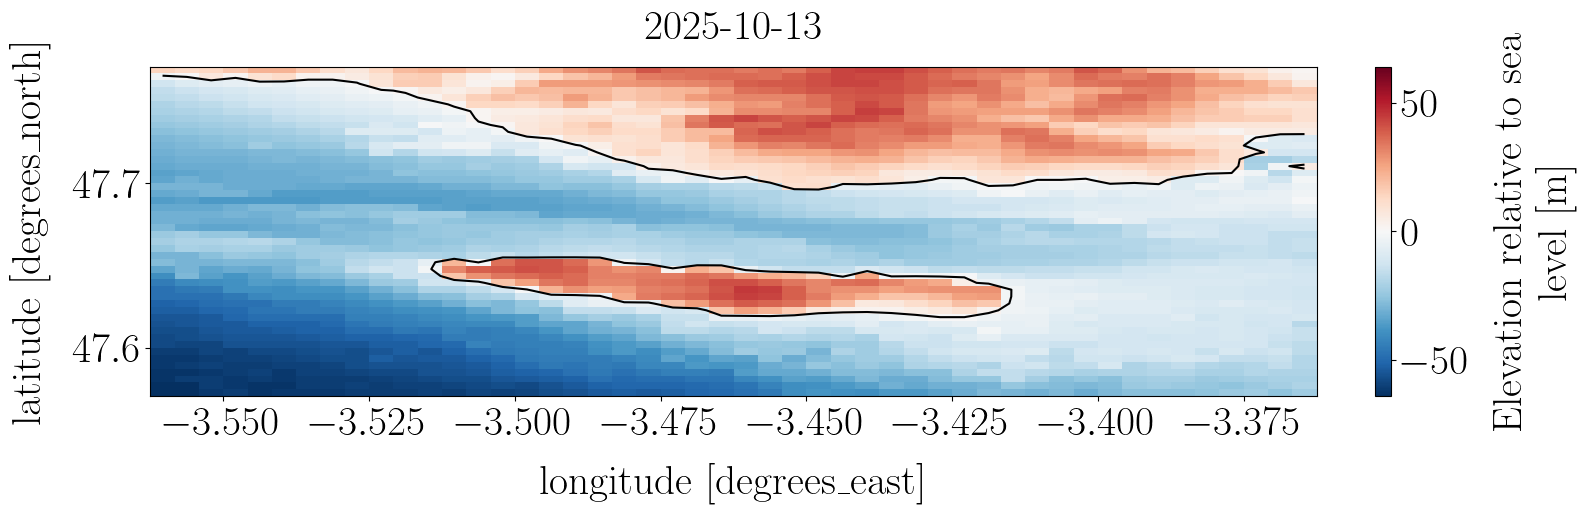

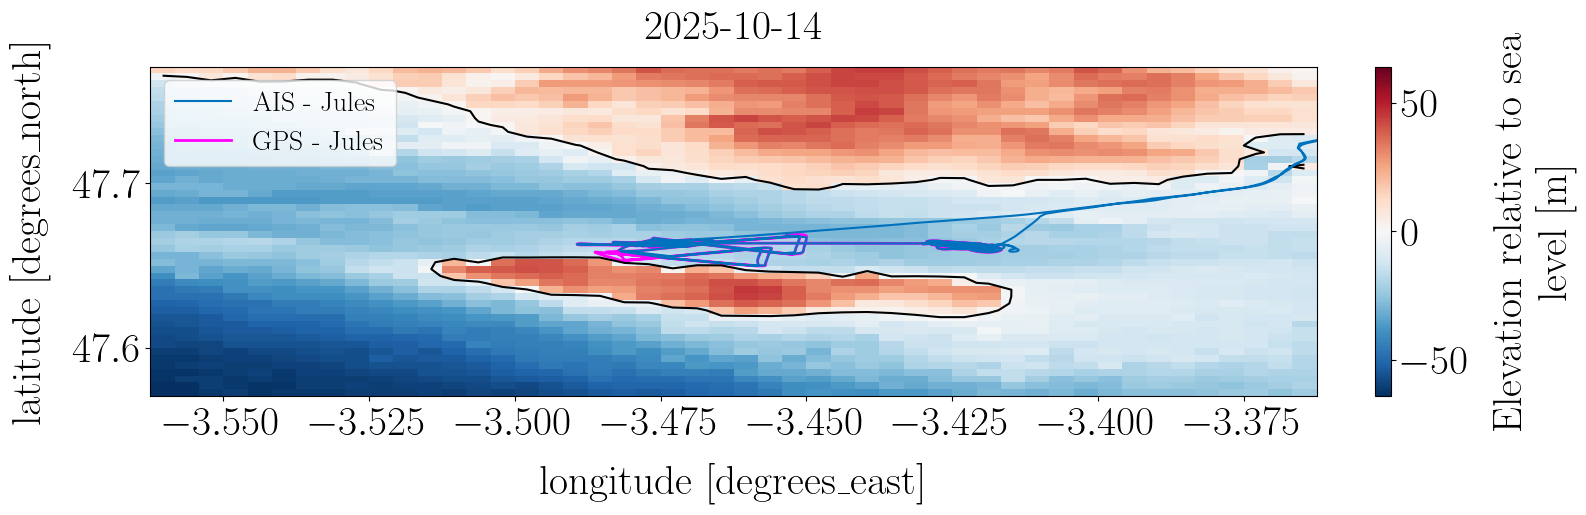

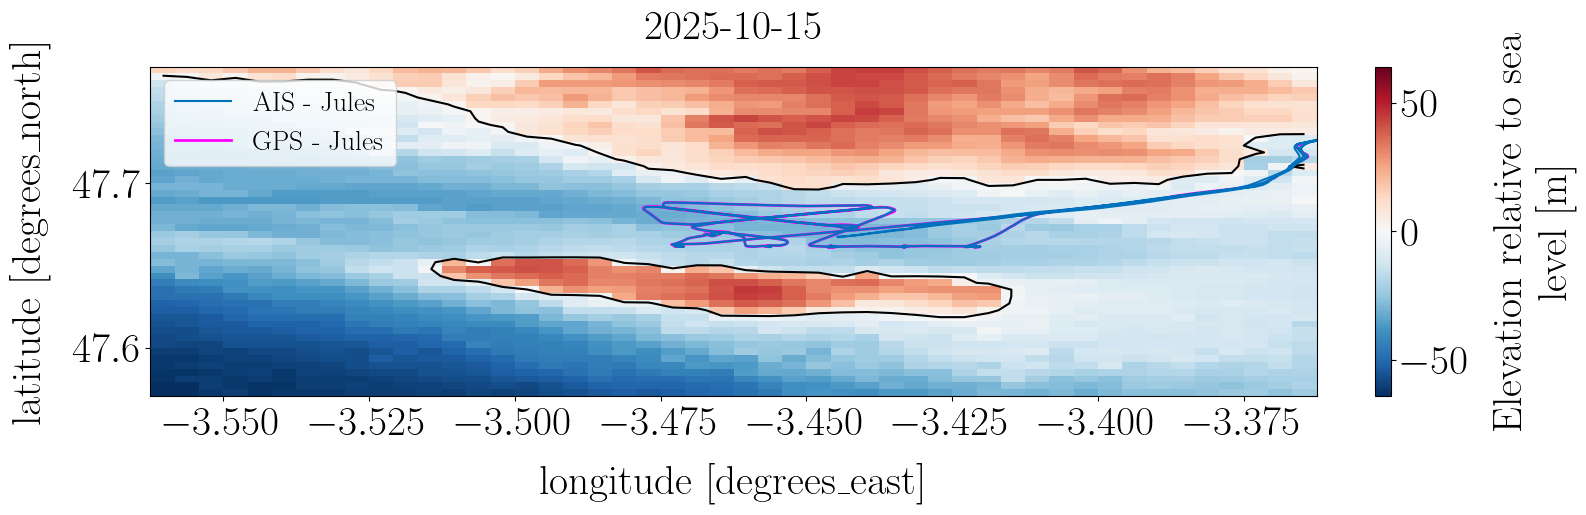

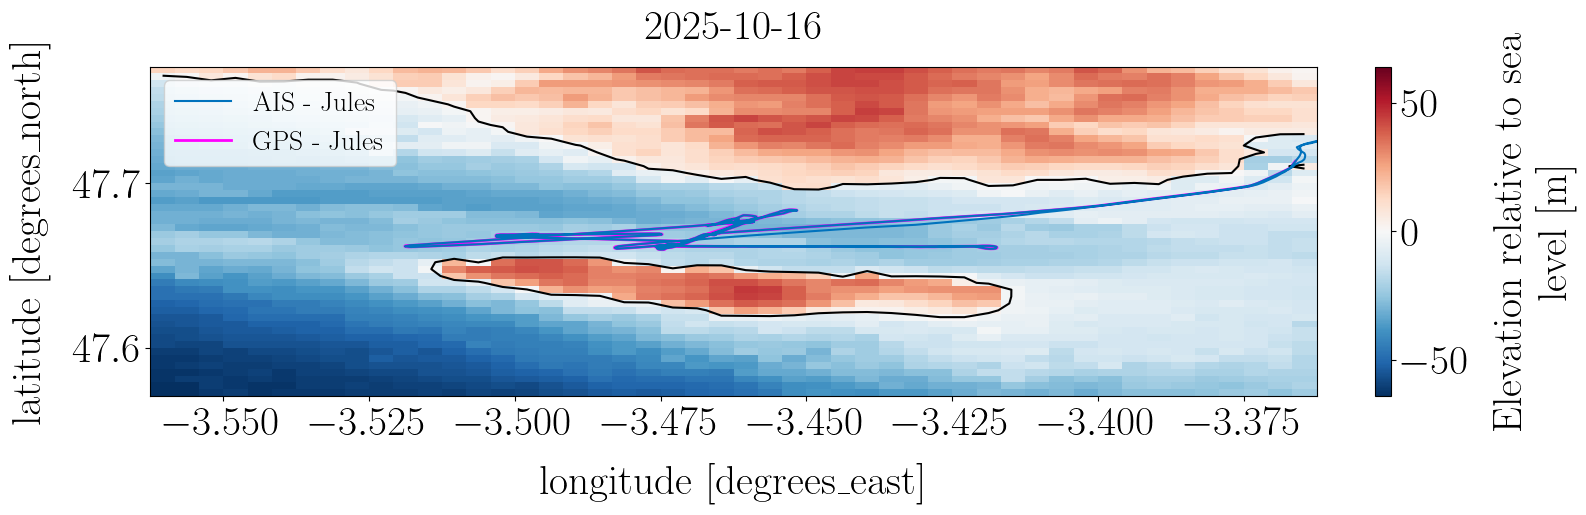

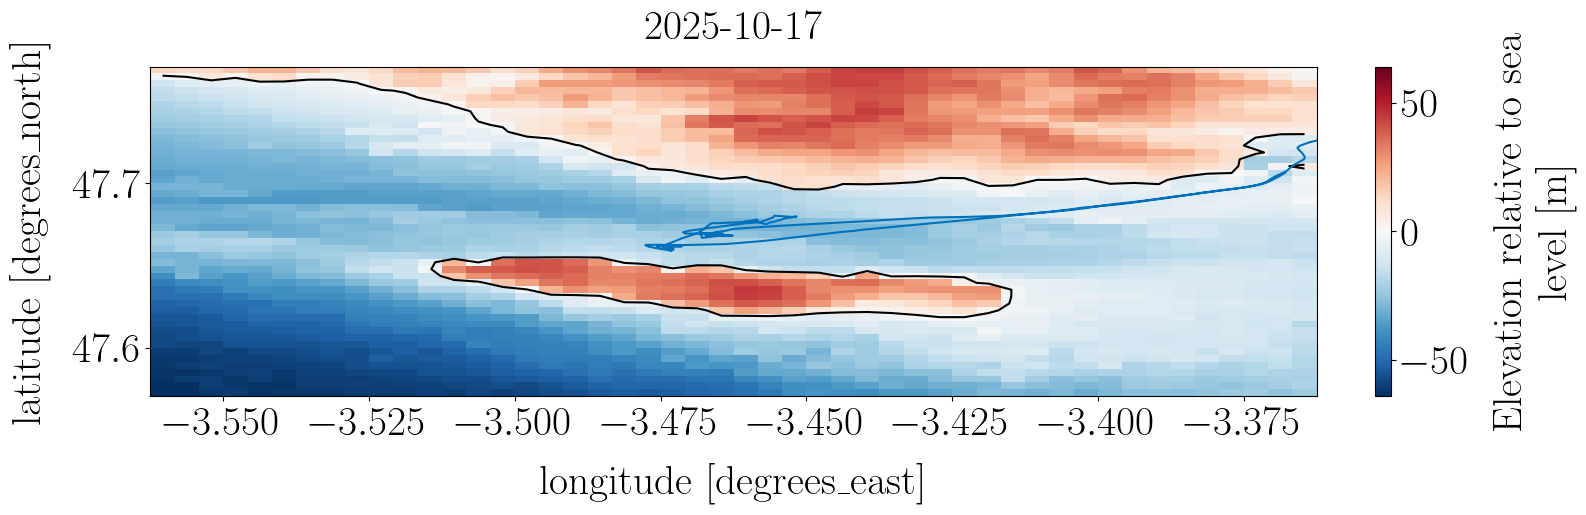

In [13]:
for date in dates:
    plot_trajectory(df_ais_spationav, date, mmsi_jules, ds_bathy,  label="AIS - Jules")

    # plot_trajectory(date, mmsi_jules, ds_bathy, label="AIS - Jules")
    date_str = date.strftime("%Y-%m-%d")
    if date_str not in gps_pos:
        continue
    
    plt.plot(
        gps_pos[date_str]["lon"],
        gps_pos[date_str]["lat"],
        color="magenta",
        label="GPS - Jules",
        zorder=1,
        linewidth=2,
    )

    # Zoom
    # plt.xlim(pos0.lon - 0.05, pos0.lon + 0.05)
    # plt.ylim(pos0.lat - 0.05, pos0.lat + 0.05)
    plt.legend()

#### Chargement d'une portion 

In [14]:
import os
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Données Bathy
bathy_fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\bathy.nc"
ds_bathy = xr.open_dataset(bathy_fpath)
# Données GPS
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\gps.nc"
ds_gps = xr.open_dataset(fpath)
# Données AIS
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\ais.nc"
ds_ais = xr.open_dataset(fpath)

t_min = "2025-10-15T08:00:00"
t_max = "2025-10-15T10:00:00"
ds_gps_t = ds_gps.sel(time=slice(t_min, t_max))
ds_gps_t = ds_gps_t.sel(raw_time=slice(t_min, t_max))
# mmsi_jules = 226916000
# ds_ais_t = ds_ais.sel(mmsi=mmsi_jules).sel(time=slice(t_min, t_max))

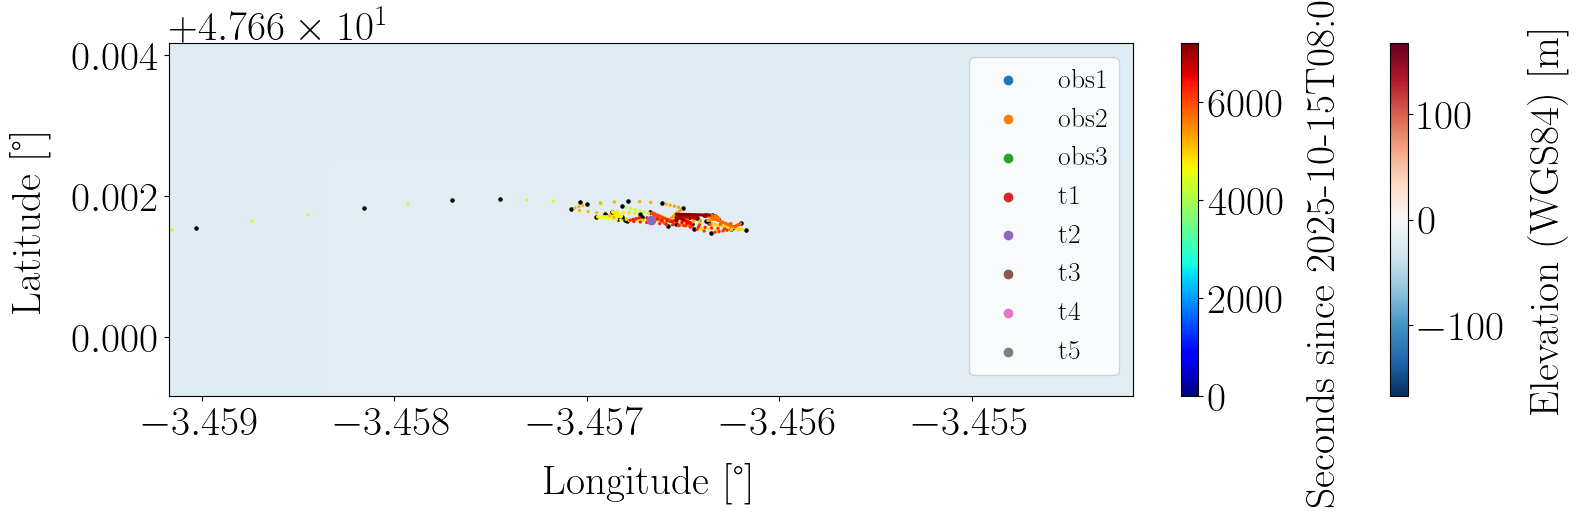

In [15]:
plt.figure()
ds_bathy.elevation.plot()
plt.contour(
    ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[-0], colors="black"
)
linear_time = (ds_gps_t.time - ds_gps_t.time.values[0]).values / np.timedelta64(1, "s")
plt.scatter(ds_gps_t.lon, ds_gps_t.lat, c=linear_time, cmap="jet", s=2, zorder=2)
plt.colorbar(label=f"Seconds since {t_min}")
plt.scatter(ds_gps_t.raw_lon, ds_gps_t.raw_lat, color="k", s=5, zorder=1)

# linear_time = (ds_ais_t.time - ds_ais_t.time.values[0]).values / np.timedelta64(1, "s")
# # plt.scatter(ds_ais_t.lon, ds_ais_t.lat, c=linear_time, cmap="jet", s=2)
# plt.plot(ds_ais_t.lon, ds_ais_t.lat, zorder=1)


dlon = 0.005
dlat = 0.005
src_pos_id = 't2'
plt.xlim(
    ds_gps.attrs[f"{src_pos_id}_lon_apriori"] - dlon / 2,
    ds_gps.attrs[f"{src_pos_id}_lon_apriori"] + dlon / 2,
)
plt.ylim(
    ds_gps.attrs[f"{src_pos_id}_lat_apriori"] - dlat / 2,
    ds_gps.attrs[f"{src_pos_id}_lat_apriori"] + dlat / 2,
)


keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    lon = ds_gps.attrs[f"{k}_lon_apriori"]
    lat = ds_gps.attrs[f"{k}_lat_apriori"]
    plt.scatter(
        lon,
        lat,
        marker="o",
        label=k,
        zorder=10,
    )

plt.legend()

#### Dans le repère ENU 

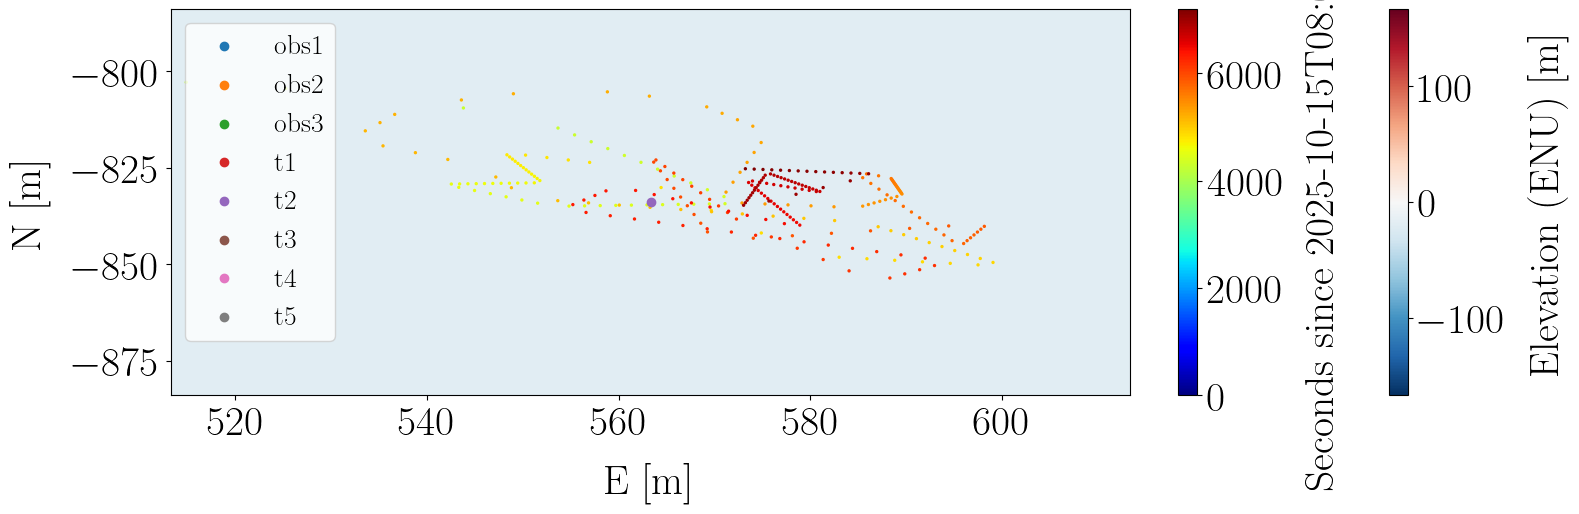

In [16]:
# Dans le repère ENU
plt.figure()
ds_bathy.elevation_enu.plot()
plt.contour(ds_bathy.e, ds_bathy.n, ds_bathy.elevation_enu, levels=[-0], colors="black")

linear_time = (ds_gps_t.time - ds_gps_t.time.values[0]).values / np.timedelta64(1, "s")
plt.scatter(ds_gps_t.e, ds_gps_t.n, c=linear_time, cmap="jet", s=2, zorder=2)
plt.colorbar(label=f"Seconds since {t_min}")

de = 100
dn = 100
src_pos_id = "t2"
plt.xlim(
    ds_gps.attrs[f"{src_pos_id}_e_apriori"] - de / 2,
    ds_gps.attrs[f"{src_pos_id}_e_apriori"] + de / 2,
)
plt.ylim(
    ds_gps.attrs[f"{src_pos_id}_n_apriori"] - dn / 2,
    ds_gps.attrs[f"{src_pos_id}_n_apriori"] + dn / 2,
)


keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="o",
        label=k,
        zorder=10,
    )

plt.legend()

Mean time difference between GPS points on 2025-10-14: 0 days 00:00:36.168521462
Max time difference between GPS points on 2025-10-14: 0 days 00:05:52
Min time difference between GPS points on 2025-10-14: 0 days 00:00:02
Mean time difference between GPS points on 2025-10-15: 0 days 00:00:40.448529411
Max time difference between GPS points on 2025-10-15: 0 days 00:03:57
Min time difference between GPS points on 2025-10-15: 0 days 00:00:04
Mean time difference between GPS points on 2025-10-16: 0 days 00:00:44.158571428
Max time difference between GPS points on 2025-10-16: 0 days 00:08:22
Min time difference between GPS points on 2025-10-16: 0 days 00:00:04


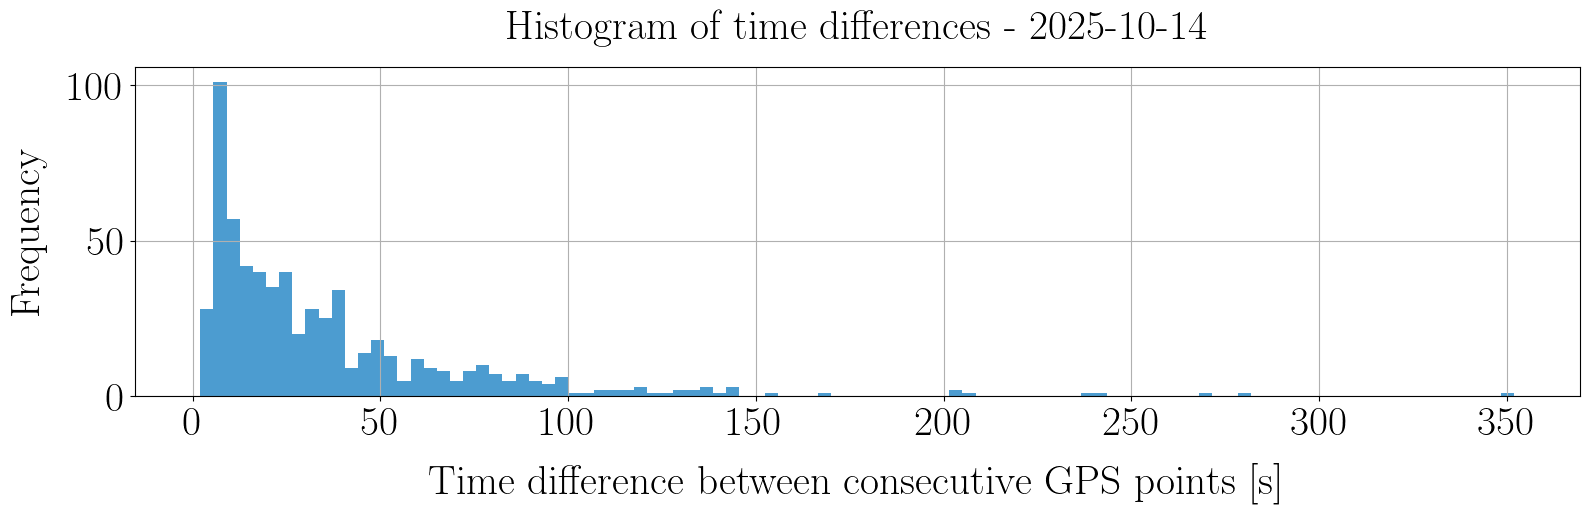

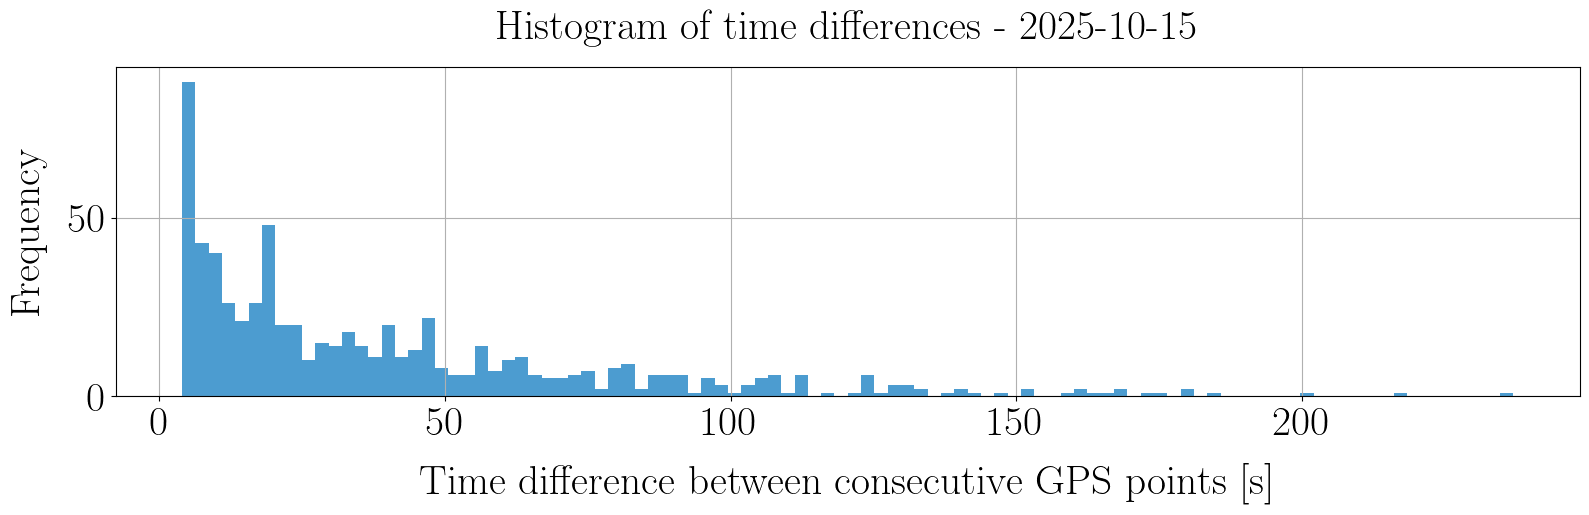

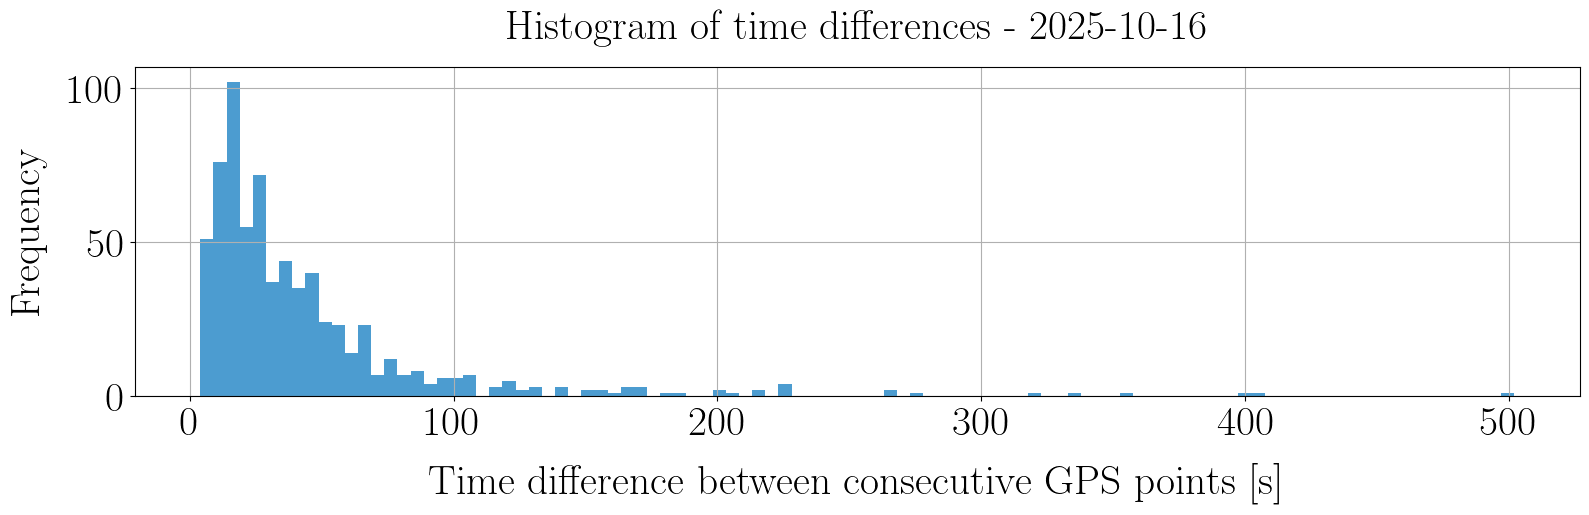

In [18]:
for date in gps_pos.keys():
    # Calculate time differences between consecutive GPS points
    time_diffs = np.diff(gps_pos[date]["datetime"])
    mean_dt = time_diffs.mean()
    # print(np.median(time_diffs))
    max_dt = time_diffs.max()
    min_dt = time_diffs.min()
    print(f"Mean time difference between GPS points on {date}:", mean_dt)
    print(f"Max time difference between GPS points on {date}:", max_dt)
    print(f"Min time difference between GPS points on {date}:", min_dt)

    # Plot time differences histogram
    time_diffs_seconds = np.array([td.total_seconds() for td in time_diffs])

    plt.figure()
    plt.hist(time_diffs_seconds, bins=100, color=color(0), alpha=0.7)
    plt.xlabel("Time difference between consecutive GPS points [s]")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of time differences - {date}")
    plt.grid()

# Bilan notebook 

## Détramage données AIS 
Code validé pour les position mais pas robuste pour extraire les instants de réception en raison de certaines trames GPS erronées. 

## Interpolation des données 
Afin de simplifier le traitement les positions peuvent être interpolées sur un vecteur de temps échantillonné régulièrement.  

## Identification de trajectoires intéressantes
L'identification des trajectoires intéressantes est faite dans un notebook dédié par soucis de clarté.  